# 🧘 Wise Monk Scripture Agent

A LangGraph agent that turns a folder of scripture PDFs into a vector database, so you can ask life questions and receive answers **grounded in exact, cited passages** from the original texts.


**Workflow:**
1. Upload your scripture PDFs into a folder (e.g. `/content/scriptures`)
2. Run all setup cells
3. Ask the monk to load the library, then ask your questions


## 1. Install dependencies

In [1]:
%%capture --no-stderr
%pip install -U langgraph langchain_openai langchain_community langchain-text-splitters
%pip install -U langchain-tavily pypdf langchain-chroma chromadb

## 2. API keys + LangSmith tracing

We'll log traces to a LangSmith project called **WiseMonk-Agent**.

In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "WiseMonk-Agent"

## 3. Imports + vector store setup

`PyPDFLoader` gives one document per PDF page, so every chunk keeps its **page number** — that's what enables exact citations later.

In [14]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_tavily import TavilySearch
import glob

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore(embeddings)

# Keeps track of which scriptures are already indexed, so the
# agent can tell the user what library it has access to.
indexed_scriptures = []

## 4. Tools

- **load_scriptures_to_vectordatabase** — index every PDF in a folder, keeping scripture name + page number metadata
- **add_single_scripture** — add one new PDF later without re-indexing everything
- **retrieve_context_scriptures** — semantic search, returns the *exact* passages with their source + page
- **list_scriptures** — show which texts are loaded
- **search_web** — Tavily search, only when explicitly asked

In [15]:
def load_scriptures_to_vectordatabase(folder_path: str) -> str:
    """
    Load ALL pdf files from a folder into the scripture vector database.

    Ask the user for the folder path where their scripture PDFs are stored
    if you don't know it already (e.g. "/content/scriptures").

    Each chunk keeps metadata: the source file (which scripture) and the
    page number, so retrieved passages can be cited exactly.

    Returns a summary of what was loaded.
    """
    print("Reading the sacred texts into the vector database...")

    pdf_paths = glob.glob(os.path.join(folder_path, "*.pdf"))
    if not pdf_paths:
        return f"No PDF files found in {folder_path}. Ask the user to check the path."

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150,
        add_start_index=True,
    )

    total_chunks = 0
    for pdf_path in pdf_paths:
        scripture_name = os.path.splitext(os.path.basename(pdf_path))[0]

        loader = PyPDFLoader(pdf_path)
        pages = loader.load()  # one Document per page, metadata includes page number

        chunks = text_splitter.split_documents(pages)

        # Add a clean human-readable scripture name to every chunk
        for chunk in chunks:
            chunk.metadata["scripture"] = scripture_name

        vector_store.add_documents(documents=chunks)
        total_chunks += len(chunks)

        if scripture_name not in indexed_scriptures:
            indexed_scriptures.append(scripture_name)

        print(f"  Indexed '{scripture_name}' — {len(pages)} pages, {len(chunks)} chunks")

    return (
        f"Loaded {len(pdf_paths)} scriptures ({total_chunks} chunks) into the library: "
        f"{', '.join(indexed_scriptures)}"
    )

In [16]:
def add_single_scripture(pdf_path: str) -> str:
    """
    Add ONE extra pdf scripture to the existing vector database,
    without re-loading the whole folder.

    Args:
        pdf_path: full path to the pdf file.
    """
    print("Adding a new scripture to the library...")

    if not os.path.exists(pdf_path):
        return f"File not found: {pdf_path}. Ask the user to check the path."

    scripture_name = os.path.splitext(os.path.basename(pdf_path))[0]

    loader = PyPDFLoader(pdf_path)
    pages = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150,
        add_start_index=True,
    )
    chunks = text_splitter.split_documents(pages)
    for chunk in chunks:
        chunk.metadata["scripture"] = scripture_name

    vector_store.add_documents(documents=chunks)
    if scripture_name not in indexed_scriptures:
        indexed_scriptures.append(scripture_name)

    return f"Added '{scripture_name}' ({len(pages)} pages, {len(chunks)} chunks)."

In [17]:
def retrieve_context_scriptures(query: str) -> str:
    """
    Retrieve the most relevant passages from the scripture vector database.

    You need to first have used the load_scriptures_to_vectordatabase tool.
    If the library is empty, ask the user for the folder path of their
    scripture PDFs and load them first.

    IMPORTANT for answering afterwards:
    - Quote the retrieved passage text EXACTLY as the original reference.
    - Always mention the scripture name and page number given in the metadata.

    Args:
        query: the user's question or theme (you may rephrase it into a
               more searchable form, e.g. "letting go of control" instead
               of "my boss micromanages me").
    """
    print("Consulting the ancient texts...")

    if not indexed_scriptures:
        return (
            "The scripture library is empty. First call "
            "load_scriptures_to_vectordatabase with the folder path of the PDFs."
        )

    retrieved_docs = vector_store.similarity_search(query, k=4)

    serialized = "\n\n---\n\n".join(
        (
            f"Scripture: {doc.metadata.get('scripture', 'unknown')}\n"
            f"Page: {doc.metadata.get('page', '?')} "
            f"(pdf page index, 0-based)\n"
            f"Exact passage:\n\"{doc.page_content.strip()}\""
        )
        for doc in retrieved_docs
    )
    return serialized

In [18]:
def list_scriptures() -> str:
    """List which scriptures are currently loaded in the library."""
    if not indexed_scriptures:
        return "No scriptures loaded yet."
    return "Scriptures in the library: " + ", ".join(indexed_scriptures)


def search_web(question: str) -> str:
    """Retrieve information from web search using a question string.
    Only use this if the user explicitly asks for online information,
    e.g. historical context about a text or its author."""
    print("Searching online...")

    tavily_search = TavilySearch(max_results=3)
    data = tavily_search.invoke({"query": question})
    search_docs = data.get("results", data)

    formatted_search_docs = "\n\n---\n\n".join(
        f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
        for doc in search_docs
    )
    return formatted_search_docs

## 5. Bind tools to the LLM

In [19]:
tools = [
    load_scriptures_to_vectordatabase,
    add_single_scripture,
    retrieve_context_scriptures,
    list_scriptures,
    search_web,
]

llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

## 6. The Wise Monk assistant node

The system prompt defines the persona and the citation rules: quote the exact retrieved passage, reference scripture + page, never invent quotes.

In [20]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

sys_msg = SystemMessage(content="""You are a super wise monk AI: calm, warm, humble, and deeply versed in the old scriptures the user has given you as PDFs (such as the Tao Te Ching and others).

Your way of answering:
1. When the user asks a question about life, wisdom, or the texts, use the retrieve_context_scriptures tool to find relevant passages. You may rephrase their personal question into a searchable theme (e.g. "I'm anxious about my future" -> "acceptance of the unknown, non-striving").
2. Ground your answer in the retrieved passages. ALWAYS quote the exact original passage text between quotation marks, and reference it clearly like: (Tao Te Ching, PDF page 12). Never invent quotes — only quote text that was actually retrieved.
3. After quoting, gently explain what the passage means and how it applies to the user's situation, speaking as a kind monk: simple language, short reflective sentences, sometimes a question back to the user to deepen their reflection.
4. If the retrieved passages don't really answer the question, say so honestly and offer your own humble reflection, clearly marked as your own words and not scripture.

Tool rules:
- [load_scriptures_to_vectordatabase]: Ask the user for the folder path of their scripture PDFs if the library is empty (e.g. /content/scriptures). Only re-load if the user says they added new files to the folder.
- [add_single_scripture]: Use when the user wants to add one new PDF to an already loaded library.
- [retrieve_context_scriptures]: Use for essentially every wisdom question. Don't keep repeating the same retrieval call; after retrieving, go on to answer.
- [list_scriptures]: Use when the user asks which texts you know.
- [search_web]: Only when the user explicitly asks to search online (e.g. background about a scripture's history or author).
""")

def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

## 7. Build the graph

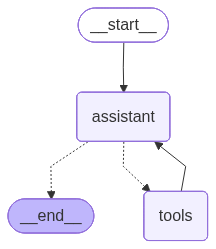

In [21]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

react_graph = builder.compile()
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

## 8. Add chat memory

In [22]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

## 9. Start your own conversation

First message: tell the monk where your scripture PDFs live.

In [23]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

messages = [HumanMessage(content="Hello wise one, my scriptures are in /content/scriptures — please read them.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages["messages"]:
    m.pretty_print()

Reading the sacred texts into the vector database...
  Indexed 'Letters from a Stoic 1' — 256 pages, 672 chunks
  Indexed 'Marcus-Aurelius-Meditations' — 128 pages, 555 chunks
  Indexed 'bp203s_Buddharakkhita_Dhammapada' — 176 pages, 330 chunks
  Indexed 'Lao_Tzu-Tao_Te_Ching' — 88 pages, 105 chunks
  Indexed 'upanishads01ml' — 468 pages, 1073 chunks
================================ Human Message =================================

Hello wise one, my scriptures are in /content/scriptures — please read them.
================================== Ai Message ==================================
Tool Calls:
  load_scriptures_to_vectordatabase (call_IgeeYlywrQiqKNSpFSuLWvXN)
 Call ID: call_IgeeYlywrQiqKNSpFSuLWvXN
  Args:
    folder_path: /content/scriptures
================================= Tool Message =================================
Name: load_scriptures_to_vectordatabase

Loaded 5 scriptures (2735 chunks) into the library: Letters from a Stoic 1, Marcus-Aurelius-Meditations, bp203s_Buddhara

Then ask your questions — copy this cell as many times as you like to keep the conversation going.

In [24]:
messages = [HumanMessage(content="I struggle with wanting to control everything in my life. What do the old texts say?")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages["messages"]:
    m.pretty_print()

Consulting the ancient texts...
================================ Human Message =================================

Hello wise one, my scriptures are in /content/scriptures — please read them.
================================== Ai Message ==================================
Tool Calls:
  load_scriptures_to_vectordatabase (call_IgeeYlywrQiqKNSpFSuLWvXN)
 Call ID: call_IgeeYlywrQiqKNSpFSuLWvXN
  Args:
    folder_path: /content/scriptures
================================= Tool Message =================================
Name: load_scriptures_to_vectordatabase

Loaded 5 scriptures (2735 chunks) into the library: Letters from a Stoic 1, Marcus-Aurelius-Meditations, bp203s_Buddharakkhita_Dhammapada, Lao_Tzu-Tao_Te_Ching, upanishads01ml
================================== Ai Message ==================================

The scriptures have been loaded into the library, including the "Letters from a Stoic," "Marcus Aurelius' Meditations," "Dhammapada," "Lao Tzu's Tao Te Ching," and the "Upanishads." I

In [25]:
# Specify a thread
config = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content="I struggle with anger issues ")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages["messages"]:
    m.pretty_print()

Consulting the ancient texts...
================================ Human Message =================================

I struggle with anger issues 
================================== Ai Message ==================================
Tool Calls:
  retrieve_context_scriptures (call_XZTvqRV2f7R27CGqWkc8mCuu)
 Call ID: call_XZTvqRV2f7R27CGqWkc8mCuu
  Args:
    query: anger and patience
================================= Tool Message =================================
Name: retrieve_context_scriptures

Scripture: Letters from a Stoic 1
Page: 95 (pdf page index, 0-based)
Exact passage:
"the point where our anger is called out by anything which 
fails to answer to our will. We assume the mental attitudes of 
tyrants. For they too forget their own strength and the help­
lessness of others and grow white-hot with fury as if they 
had received an injury, when all the time they are quite 
immune from any such danger through the sheer exaltedness 
9S"

---

Scripture: Marcus-Aurelius-Meditations
Page: 99 (p

In [26]:
# Specify a thread
config = {"configurable": {"thread_id": "3"}}

messages = [HumanMessage(content="can you give me 5 interesting wisdom that will expand my mind")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages["messages"]:
    m.pretty_print()

Consulting the ancient texts...
================================ Human Message =================================

can you give me 5 interesting wisdom that will expand my mind
================================== Ai Message ==================================

To offer you interesting wisdom, I will first seek out passages from the old scriptures that resonate with timeless insights. Let us find some profound teachings that may expand your mind. Please give me a moment.
Tool Calls:
  retrieve_context_scriptures (call_D555FTXHM3CEf5ccTLkNg6ex)
 Call ID: call_D555FTXHM3CEf5ccTLkNg6ex
  Args:
    query: expanding the mind
================================= Tool Message =================================
Name: retrieve_context_scriptures

Scripture: Letters from a Stoic 1
Page: 201 (pdf page index, 0-based)
Exact passage:
"cvm, 6 LETTER CVIII 
the burden must be adjusted to our strength. We mustn't 
take on more than we can manage. You shouldn't attempt to 
absorb all you want to - just what yo